# MACHINE LEARNING IMPLEMENTATION (SUPPORT VECTOR MACHINE)

# Problem statement
This project seeks to use support vector machine (SVM) algorithm predict accident severity in Malta, based on some features or factors from press release and police report data sources. Based on this data, the model will classify accidents into 4 severity categories namely; None, Minor, Serious, Fatal. The main objective is to identify the factors that could influence the severity or occurence of an accident. This will help the goverment to create road safety policies, identify dangerous conditions, and high-risk areas and time where accidents are prone to occur.

# 1) What factors influences accident severity in Malta?

# Data Processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [707]:
# Load the dataset
df = pd.read_csv('data/dataset.csv')

In [708]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (682, 24)


In [709]:
print(df.head())

   person_id  article_id   age  gender severity is_driver vehicle_type  \
0          0        4208  78.0    male     none      True          car   
1          1        4093  54.0    male  serious      True   motorcycle   
2          2        4110  54.0    male  serious      True   motorcycle   
3          3        4066  17.0  female  serious     False          NaN   
4          4        4066  52.0    male     none      True          car   

  person_state  accident_id            date_time  ... windspeed_10m  \
0          NaN          0.0  2024-12-04 17:00:00  ...           9.8   
1          NaN          1.0  2024-12-11 17:00:00  ...           6.5   
2          NaN          2.0  2024-12-11 13:00:00  ...           5.0   
3          NaN          3.0  2024-12-13 17:30:00  ...          24.0   
4          NaN          3.0  2024-12-13 17:30:00  ...          24.0   

  cloud_cover  weather_code  is_weekday  is_public_holiday  time_of_day  \
0       100.0           3.0        True              

In [710]:
print(f"\nColumns: {df.columns.tolist()}")


Columns: ['person_id', 'article_id', 'age', 'gender', 'severity', 'is_driver', 'vehicle_type', 'person_state', 'accident_id', 'date_time', 'accident_type', 'location', 'temperature_2m', 'precipitation', 'windspeed_10m', 'cloud_cover', 'weather_code', 'is_weekday', 'is_public_holiday', 'time_of_day', 'month', 'hour', 'day', 'year']


Removng unnecesary features.

In [711]:
df.drop('person_id', inplace=True, axis=1)
df.drop('article_id', inplace=True, axis=1)
df.drop('accident_id', inplace=True, axis=1)
df.drop('date_time', inplace=True, axis=1)
df.drop('weather_code', inplace=True, axis=1)

In [712]:
print(f"\nColumns: {df.columns.tolist()}")


Columns: ['age', 'gender', 'severity', 'is_driver', 'vehicle_type', 'person_state', 'accident_type', 'location', 'temperature_2m', 'precipitation', 'windspeed_10m', 'cloud_cover', 'is_weekday', 'is_public_holiday', 'time_of_day', 'month', 'hour', 'day', 'year']


In [713]:
# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
age                   64
gender               101
severity              21
is_driver              4
vehicle_type         114
person_state         665
accident_type          0
location              39
temperature_2m         0
precipitation          0
windspeed_10m          0
cloud_cover            0
is_weekday             0
is_public_holiday      0
time_of_day           80
month                  0
hour                  80
day                    0
year                   0
dtype: int64


In [714]:
# Check target variable
if 'Severity' in df.columns:
    target_col = 'Severity'
elif 'severity' in df.columns:
    target_col = 'severity'
# Find target column (assuming it contains 'severity' in name)
    target_cols = [col for col in df.columns if 'severity' in col.lower()]
    target_col = target_cols[0] if target_cols else df.columns[-1]
    df['severity'] = df['severity'].replace('critical', 'serious')

In [715]:
print(f"\nTarget column: {target_col}")
print(f"Target distribution:")
print(df[target_col].value_counts())
print(f"\nTarget percentages:")
print(df[target_col].value_counts(normalize=True) * 100)


Target column: severity
Target distribution:
severity
none       280
serious    255
fatal       82
minor       44
Name: count, dtype: int64

Target percentages:
severity
none       42.360061
serious    38.577912
fatal      12.405446
minor       6.656581
Name: proportion, dtype: float64


# Data cleaning

In [716]:
# Make a copy
df_clean = df.copy()

In [717]:
# Handle missing values - simple approach
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("Missing values handled!")
print(f"\nMissing values per column after imputation:")
print(df_clean.isnull().sum())

Missing values handled!

Missing values per column after imputation:
age                  0
gender               0
severity             0
is_driver            0
vehicle_type         0
person_state         0
accident_type        0
location             0
temperature_2m       0
precipitation        0
windspeed_10m        0
cloud_cover          0
is_weekday           0
is_public_holiday    0
time_of_day          0
month                0
hour                 0
day                  0
year                 0
dtype: int64


In [718]:
# Remove duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {initial_rows - len(df_clean)} duplicate rows")

Removed 27 duplicate rows


 Features Selection

In [721]:
# Assume your cleaned dataframe is called df

# Numeric columns
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)


Numeric Columns:
['age', 'temperature_2m', 'precipitation', 'windspeed_10m', 'cloud_cover', 'month', 'hour', 'day', 'year']

Categorical Columns:
['gender', 'severity', 'is_driver', 'vehicle_type', 'person_state', 'accident_type', 'location', 'is_weekday', 'is_public_holiday', 'time_of_day']


In [862]:
# Separate features and target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

In [863]:
# Encode target if it's categorical
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print(f"Target classes: {le_target.classes_}")


Target classes: ['fatal' 'minor' 'none' 'serious']


# TRAIN-TEST SPLIT

In [864]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=None
    )

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")



Training set: (524, 18)
Test set: (131, 18)


Feature Encoding and Scalling

In [866]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Encoding + scaling completed.")


Encoding + scaling completed.


BUILD AND TRAIN SVM MODEL

In [867]:
#  SVM model 
print("Training baseline SVM model...")
svm_baseline = SVC(
    kernel='rbf', 
    random_state=42, 
    probability=True
)
svm_baseline.fit(X_train_processed, y_train)

# Make predictions
y_pred = svm_baseline.predict(X_test_processed)



Training baseline SVM model...


HYPERPARAMETER TUNING

In [868]:
# Pipeline with SVM
pipe = Pipeline([
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf', 'poly']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train_processed, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}


# Final Model Evaluation

Prediction

In [869]:
y_pred = best_model.predict(X_test_processed)
y_prob = best_model.predict_proba(X_test_processed)

Classification Report

In [733]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.549618320610687

Classification Report:
               precision    recall  f1-score   support

       fatal       0.16      0.27      0.20        15
       minor       0.12      0.40      0.18         5
        none       0.74      0.67      0.70        64
     serious       0.74      0.49      0.59        47

    accuracy                           0.55       131
   macro avg       0.44      0.46      0.42       131
weighted avg       0.65      0.55      0.59       131



 Confusion Matrix

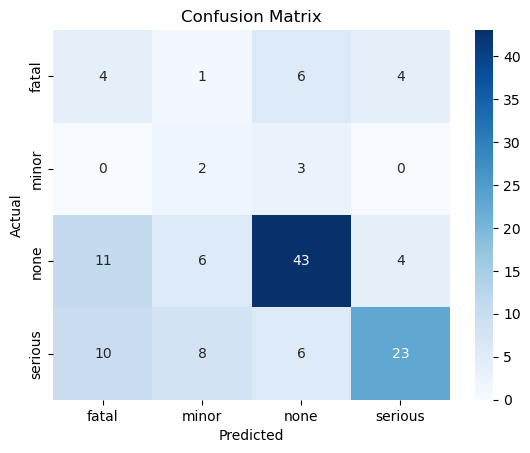

In [700]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ROC-AUC (one-vs-rest)

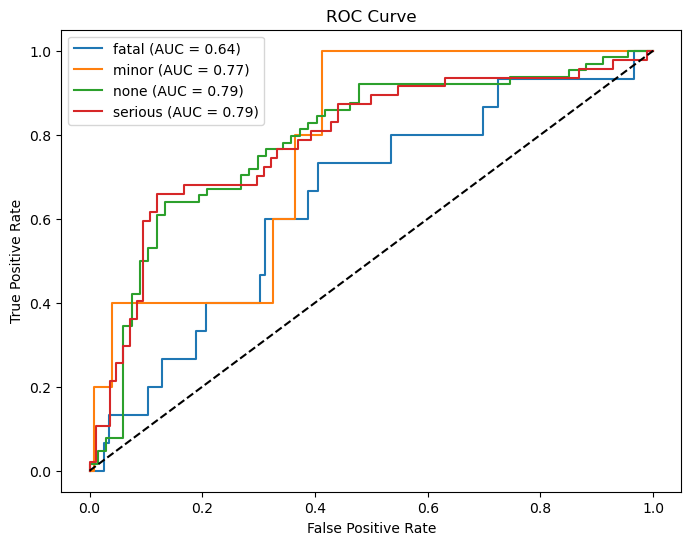

Overall Weighted ROC-AUC: 0.7700519731778941


In [734]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

overall_auc = roc_auc_score(y_test_bin, y_prob, average='weighted')
print("Overall Weighted ROC-AUC:", overall_auc)

# FEATURE IMPORTANCE

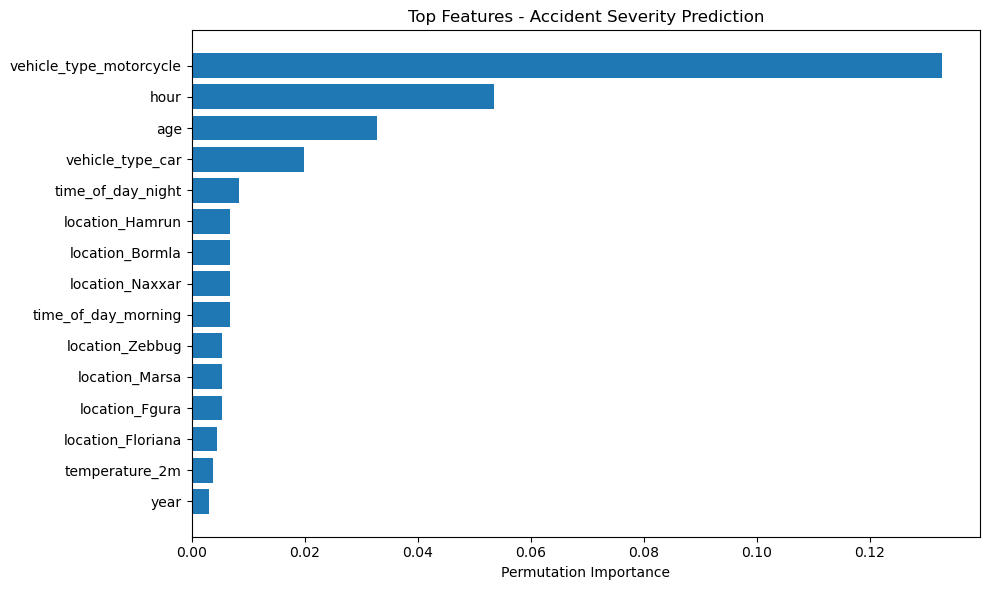

In [870]:
import matplotlib.pyplot as plt

top_n = min(15, len(feature_importance))
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'].head(top_n)[::-1],
         feature_importance['Importance'].head(top_n)[::-1])
plt.xlabel("Permutation Importance")
plt.title("Top Features - Accident Severity Prediction")
plt.tight_layout()
plt.show()

In [703]:
# Total importance
total_importance = feature_importance['Importance'].sum()

# Add percentage column
feature_importance['Contribution_%'] = (
    feature_importance['Importance'] / total_importance
) * 100

# Sort again just in case
feature_importance = feature_importance.sort_values('Contribution_%', ascending=False)

# Show top 10 with percentages
print(feature_importance.head(10))

                     Feature  Importance  Contribution_%
15   vehicle_type_motorcycle    0.132824       70.161290
6                       hour    0.053435       28.225806
0                        age    0.032824       17.338710
13          vehicle_type_car    0.019847       10.483871
115        time_of_day_night    0.008397        4.435484
56           location_Hamrun    0.006870        3.629032
39           location_Bormla    0.006870        3.629032
79           location_Naxxar    0.006870        3.629032
114      time_of_day_morning    0.006870        3.629032
109          location_Zebbug    0.005344        2.822581


# Interpretations

a) Model Performance

Accuracy of  0.55% indicates that the model correctly predicts the accident severity 55% of the time which is considered higher than random guessing (25% for four classes), so the model has learned some meaningful patterns.

Weighted ROC-AUC of 0.77 Indicates that, overall, the model can discriminate reasonably well between severity classes as a ROC-AUC above 0.7 is considered decent for a multi-class problem. Also, fro the classification report, it shows that model is more confident in predicting no accident or serious accidents but struggles with rare cases (fatal or minor).

b) Feature Importance
- Vehicle type (motorcycle) dominates, contributing 70% to the model’s predictive power. This means that motorcycles are often involved in more severe accidents.

- Hour of the day contributes significantly (~28%). Certain times (rush hours, night) may have higher accident severity.

- Age and vehicle type (car) also play a role, but less than motorcycles or time.

- Other factors like location and time of day categories have smaller contributions (<5%).
Conclusively, this means that main factors of accident severity: Motorcycle usage and  during specific time of day/hour(morning or night). Also, Driver age and type of vehicle (car) are other key factors to look at to reduce accident occurance in Malta.


# 2) Predicting Accidents occurence from weather Factors?

In [ ]:
#  Import libraries
# ------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


Encoding Target Feature

In [1067]:
# Clean severity column
df["severity"] = df["severity"].astype(str).str.lower().str.strip()

valid_classes = ["none", "minor", "serious", "fatal"]
df = df[df["severity"].isin(valid_classes)]

# Encode severity
le_sev = LabelEncoder()
df["severity_encoded"] = le_sev.fit_transform(df["severity"])

print("Severity mapping:", dict(zip(le_sev.classes_, le_sev.transform(le_sev.classes_))))


Severity mapping: {'fatal': 0, 'minor': 1, 'none': 2, 'serious': 3}


In [1068]:
num_cols = [
    "temperature_2m",
    "precipitation",
    "windspeed_10m",
    "cloud_cover"
]



In [1082]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ]
)


In [1070]:
print(X_train.columns.tolist())


['temperature_2m', 'precipitation', 'windspeed_10m', 'cloud_cover']


Feature Selection

In [ ]:


print("Final data shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Final data shape: (660, 4)
Target distribution:
 severity_encoded
2    280
3    254
0     82
1     44
Name: count, dtype: int64


 Train/Test Split

In [1072]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Feature Scaling

In [1073]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)


Hyperparameter Tuning

In [1074]:
pipe = Pipeline([
    ("prep", preprocessor),
    ("svm", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.1],
    "svm__kernel": ["rbf"]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


In [1075]:

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight=class_weight,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("svm", svm_model)
])

In [1076]:
# 1. Train the model first
svm_model.fit(X_train_scaled, y_train)

# 2. Then make predictions
y_pred = svm_model.predict(X_test_scaled)

In [1077]:
# Extract best parameters from GridSearch
best_params = grid.best_params_

# Build final SVM model with best parameters
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        probability=True,
        class_weight="balanced",
        C=best_params["svm__C"],
        gamma=best_params["svm__gamma"],
        kernel=best_params["svm__kernel"]
    ))
])

# Train final model
best_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, class_weight='balanced', probability=True))])

Results and Evaluation

Accuracy: 0.26515151515151514

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.25      0.22        16
           1       0.12      0.67      0.20         9
           2       0.46      0.21      0.29        56
           3       0.37      0.25      0.30        51

    accuracy                           0.27       132
   macro avg       0.29      0.35      0.25       132
weighted avg       0.37      0.27      0.28       132



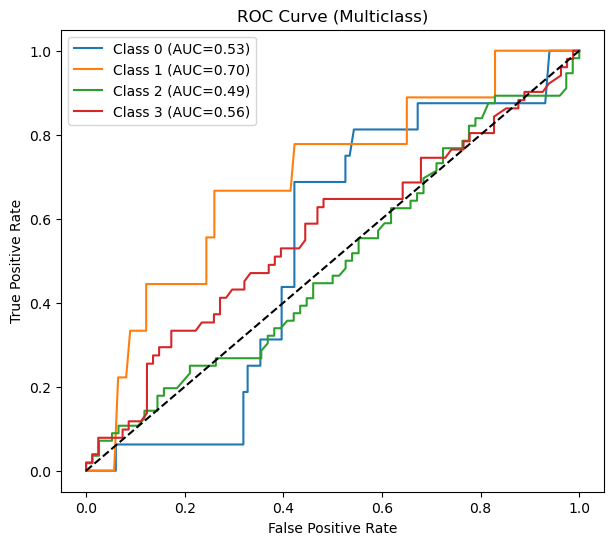

Overall Weighted ROC-AUC: 0.5388144987095713


In [1078]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

# -----------------------------
# 2. Accuracy & Report
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# -----------------------------
# ROC Curve (Multiclass)
# -----------------------------
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC={auc_score:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass)")
plt.legend()
plt.show()

# -----------------------------
# Overall AUC (Weighted)
# -----------------------------
overall_auc = roc_auc_score(y_test_bin, y_prob, average="weighted", multi_class="ovr")
print("Overall Weighted ROC-AUC:", overall_auc)


Confusion Matrix

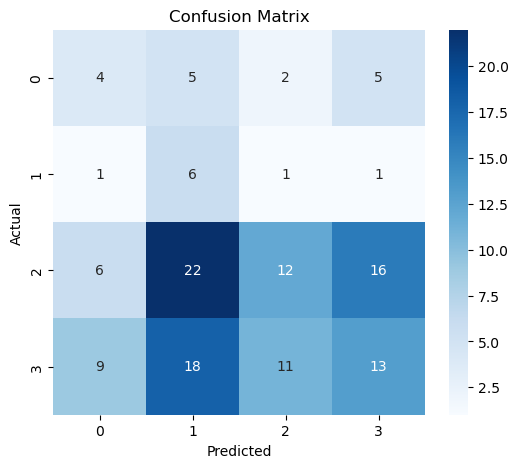

In [1080]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


 Feature Importance and their contributions


Feature Contribution (%):
          feature  importance  percentage
1   precipitation    0.040909   39.416058
2   windspeed_10m    0.035606   34.306569
3     cloud_cover    0.013636   13.138686
0  temperature_2m    0.013636   13.138686


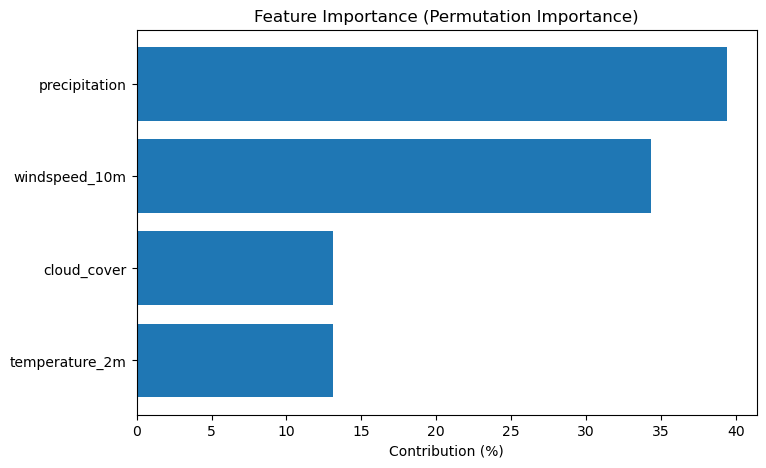

In [1081]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Permutation Importance
# -----------------------------
result = permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# Create DataFrame
feat_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
})

# Sort by importance
feat_importances = feat_importances.sort_values(by="importance", ascending=False)

# -----------------------------
# 2. Convert to Percentage
# -----------------------------
total_importance = feat_importances["importance"].sum()
feat_importances["percentage"] = (feat_importances["importance"] / total_importance) * 100

print("\nFeature Contribution (%):")
print(feat_importances)

# -----------------------------
# 3. Plot Feature Importance
# -----------------------------
plt.figure(figsize=(8,5))
plt.barh(feat_importances["feature"], feat_importances["percentage"])
plt.xlabel("Contribution (%)")
plt.title("Feature Importance (Permutation Importance)")
plt.gca().invert_yaxis()
plt.show()


# Interpretation of Results

 a) Overall Performance
Accuracy = 0.27

This means that the model correctly predicts accident severity only about 27% of the time, which is low.
However, accuracy alone is misleading because, this accuracy score could be due to issues in the dataset like class imbalance which forces the model to predict minority classes most of the time. This causes the model is over-predicting minority classes (minor, fatal) to compensate for imbalance. This improves recall for rare classes.

b) ROC-AUC = 0.54

ROC-AUC measures ranking ability. 0.54 score is only slightly better than random. this means that, Weather features alone provide very weak predictive signal for accident severity, this leads to low accuracy.

c) Feature Contribution (Permutation Importance)

- Precipitation (39.42%)
Precipitation is the most influential weather feature in the model's prediction results. This suggests that rainfall or other forms of precipitation have the strongest relationship with accident severity. Wet or slippery road conditions likely increase the risk of severe accidents.

- Wind Speed (34.31%)
Wind speed is the second most important feature. Strong winds can reduce vehicle stability, affect visibility (due to dust or rain), and make driving more difficult, which may increase accident severity.

- Cloud Cover (13.14%)
Cloud cover has a moderate effect. High cloud cover usually means lower visibility and darker driving conditions, which can contribute to accidents, but its effect is weaker compared to precipitation and wind.

- Temperature (13.14%)
Temperature has a similar influence as cloud cover. Extreme temperatures (very hot or very cold) may indirectly affect driving conditions (e.g., icy roads in cold weather or driver fatigue in hot weather), but overall it plays a smaller role compared to precipitation and wind.

Conclusion

This implies that, road safety agencies should focus more on managing risks during rainy and windy conditions to reduce accident accurance and its severity when it occurs.

Also, warning systems and traffic advisories should prioritize precipitation and wind forecasts.